### Project Objective :- 
### “Predict building energy consumption using Linear Regression and perform Exploratory Data Analysis”.

In [1]:
# Step 1: Import libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
import os

warnings.filterwarnings('ignore')
%matplotlib inline

In [4]:
# Step 2: Load dataset
# Data set taken from kaggle ----
# https://www.kaggle.com/datasets/govindaramsriram/energy-consumption-dataset-linear-regression?resource=download
train = pd.read_csv("train_energy_data.csv")

test_data = pd.read_csv("test_energy_data.csv")

In [4]:
# Step 3: Explore data

train.head(10)

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
5,Commercial,37377,26,32,16.24,Weekend,4687.67
6,Industrial,38638,92,14,21.01,Weekend,5526.83
7,Residential,34950,60,18,28.24,Weekday,4116.32
8,Industrial,29741,99,44,13.08,Weekday,5841.65
9,Residential,17467,42,36,28.84,Weekday,3419.13


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   str    
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   str    
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 54.8 KB


In [6]:
train.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1000.000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25462.388,48.372000,25.606000,22.611390,4166.252570
std,14294.554,29.061972,14.105166,7.139943,933.313064
min,560.000,1.000000,1.000000,10.050000,1683.950000
25%,13169.750,22.000000,13.000000,16.475000,3509.482500
50%,25477.000,47.000000,26.000000,22.815000,4175.730000
75%,37446.250,73.250000,38.000000,28.850000,4863.850000
max,49997.000,99.000000,49.000000,34.990000,6530.600000


In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Square Footage,1000.0,25462.38800,14294.554000,560.00,13169.7500,25477.000,37446.25,49997.00
Number of Occupants,1000.0,48.37200,29.061972,1.00,22.0000,47.000,73.25,99.00
Appliances Used,1000.0,25.60600,14.105166,1.00,13.0000,26.000,38.00,49.00
Average Temperature,1000.0,22.61139,7.139943,10.05,16.4750,22.815,28.85,34.99
Energy Consumption,1000.0,4166.25257,933.313064,1683.95,3509.4825,4175.730,4863.85,6530.60


In [8]:
train.nunique() # By this code we got know here we have two categories in our dataset

Building Type             3
Square Footage          986
Number of Occupants      99
Appliances Used          49
Average Temperature     833
Day of Week               2
Energy Consumption     1000
dtype: int64

In [9]:
print(train['Building Type'].unique())
print(train['Day of Week'].unique())

<StringArray>
['Residential', 'Commercial', 'Industrial']
Length: 3, dtype: str
<StringArray>
['Weekday', 'Weekend']
Length: 2, dtype: str


In [10]:
train['Building Type'].nunique()

3

In [11]:
train.value_counts('Building Type')

Building Type
Residential    347
Commercial     336
Industrial     317
Name: count, dtype: int64

<Axes: xlabel='Building Type', ylabel='count'>

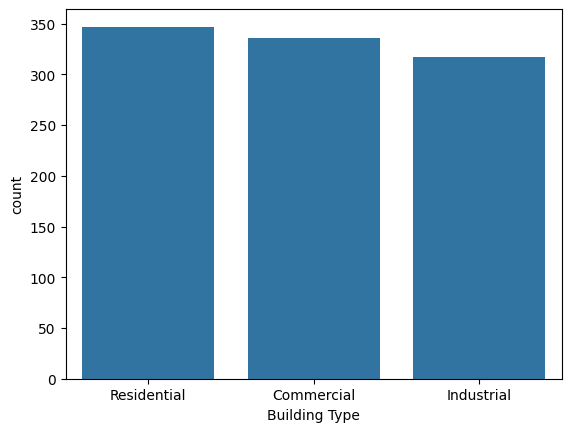

In [12]:
sns.countplot(x = train['Building Type'])

In [13]:
train.value_counts('Day of Week')

Day of Week
Weekday    507
Weekend    493
Name: count, dtype: int64

<Axes: xlabel='Day of Week', ylabel='count'>

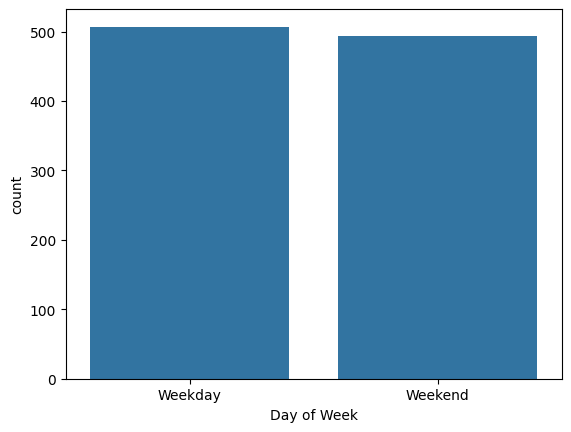

In [14]:
sns.countplot(x= train['Day of Week'])

In [15]:
train.head(8)

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
5,Commercial,37377,26,32,16.24,Weekend,4687.67
6,Industrial,38638,92,14,21.01,Weekend,5526.83
7,Residential,34950,60,18,28.24,Weekday,4116.32


In [8]:
data_numeric = train.select_dtypes(include = 'number')
data_numeric

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
0,7063,76,10,29.84,2713.95
1,44372,66,45,16.72,5744.99
2,19255,37,17,14.30,4101.24
3,13265,14,41,32.82,3009.14
4,13375,26,18,11.92,3279.17
...,...,...,...,...,...
995,14419,68,44,23.95,3661.21
996,12194,7,22,14.67,3546.34
997,39562,88,20,32.18,5147.21
998,8348,67,37,16.48,3244.98


In [9]:
data_numeric.nunique()

Square Footage          986
Number of Occupants      99
Appliances Used          49
Average Temperature     833
Energy Consumption     1000
dtype: int64

In [10]:
data_numeric.corr()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
Square Footage,1.000000,0.033379,-0.013478,0.027273,0.774873
Number of Occupants,0.033379,1.000000,0.023646,0.014122,0.354485
Appliances Used,-0.013478,0.023646,1.000000,-0.062870,0.312792
Average Temperature,0.027273,0.014122,-0.062870,1.000000,-0.034487
Energy Consumption,0.774873,0.354485,0.312792,-0.034487,1.000000


<Axes: >

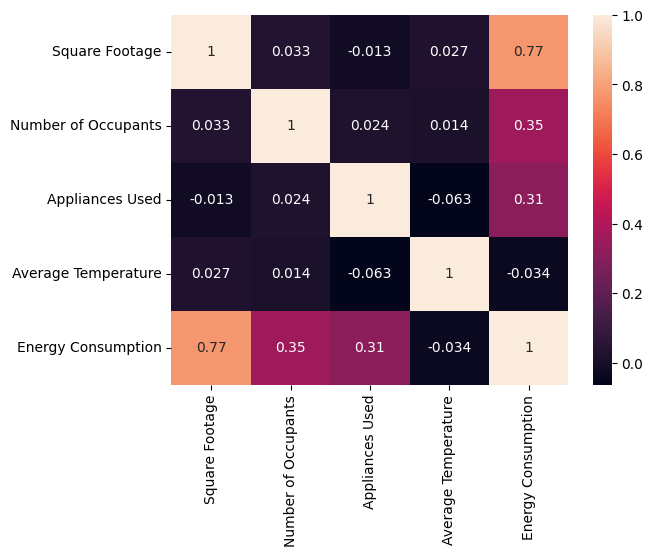

In [11]:
sns.heatmap(data_numeric.corr(), annot = True, cbar = True)

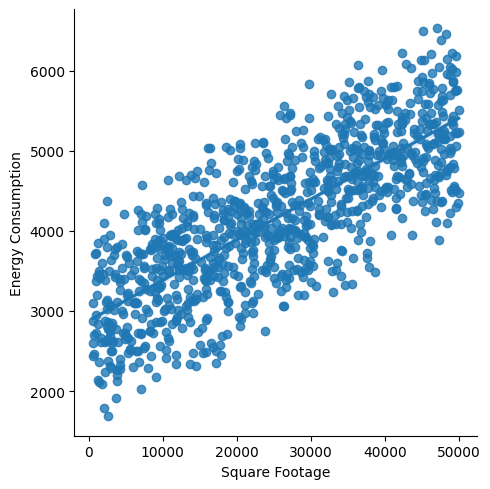

In [9]:
sns.lmplot(y="Energy Consumption", x="Square Footage", data=data_numeric)

<Axes: ylabel='Energy Consumption'>

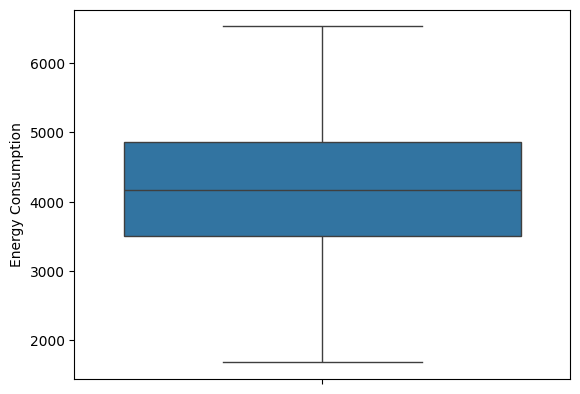

In [14]:
sns.boxplot(train['Energy Consumption'])

<Axes: ylabel='Square Footage'>

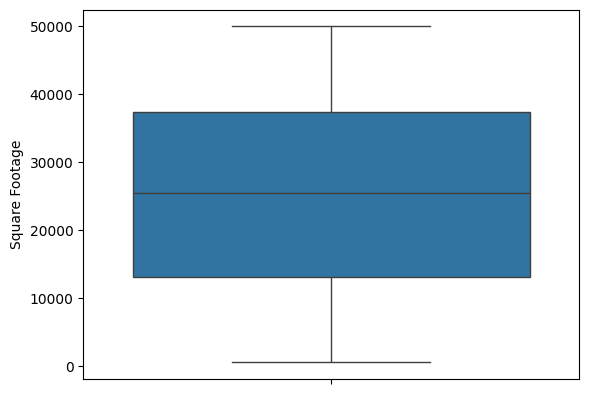

In [15]:
sns.boxplot(train["Square Footage"])

Slope :-  0.05059260443164519
Intercept :-  2878.04404603093
R_value :-  0.774872594798946
P_value :-  5.115950281684812e-201
Std_err :-  0.001306439309897569


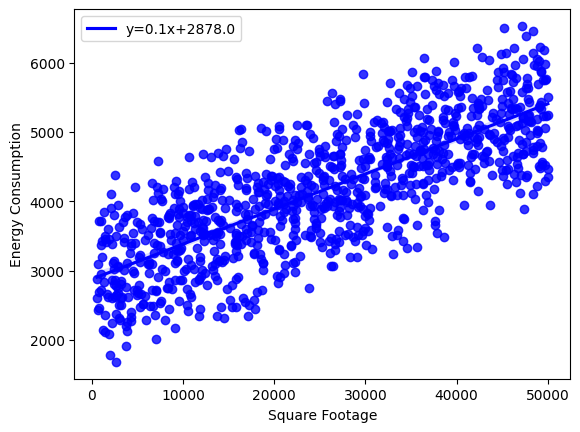

In [27]:
from scipy import stats

# get coefficients of linear fit
slope, intercept, r_value, p_value, std_err = stats.linregress(train['Square Footage'],train["Energy Consumption"])
print("Slope :- ",slope)
print("Intercept :- ",intercept)
print("R_value :- ",r_value) 
print("P_value :- ",p_value)
print("Std_err :- ",std_err) 

# use line_kws to set line label for legend
df = sns.regplot(x='Square Footage', y="Energy Consumption", data=train, color='b', 
                 line_kws={'label':"y={0:.1f}x+{1:.1f}".format(slope,intercept)})

# plot legend
df.legend()

plt.show()

In [3]:
# Step 4: Visualization - Energy Consumption by Building Type
data_by_type = train.groupby('Building Type')['Energy Consumption'].sum().reset_index()
data_by_type

,Building Type,Energy Consumption
0,Commercial,1387687.92
1,Industrial,1501040.21
2,Residential,1277524.44


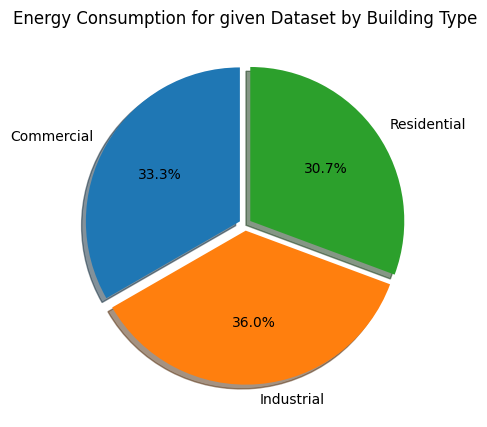

In [17]:
# Step 4: Visualization - Energy Consumption by Building Type
plt.figure(figsize = (10,5))
plt.pie(data_by_type['Energy Consumption'],
        labels = data_by_type['Building Type'],
        autopct ='%1.1f%%',                   # For adding percentage
        startangle = 90,                      # Start angle for first slice
        shadow = True,                        # Add shadow effect
        explode = [0.04]*len(data_by_type) )  # Slightly explode all slices
plt.title('Energy Consumption for given Dataset by Building Type')
plt.show()

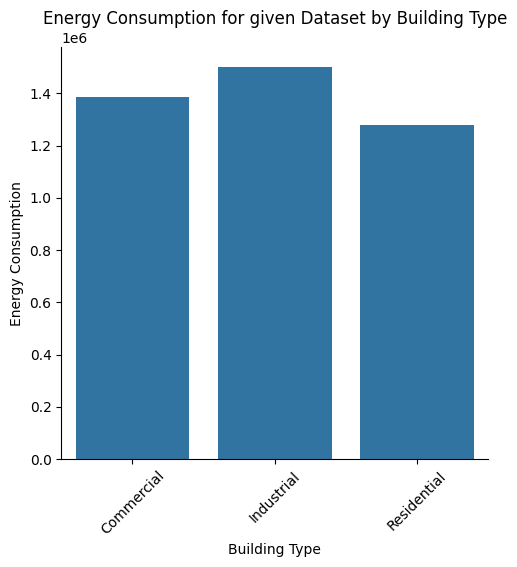

In [21]:
sns.catplot(x='Building Type', y='Energy Consumption', 
            kind='bar', height=5, data=data_by_type)
plt.title('Energy Consumption for given Dataset by Building Type')
plt.xticks(rotation=45)
plt.show()

In [13]:
# Step 5: Visualization - Energy Consumption by Day of Week
data_by_day_of_week = train.groupby('Day of Week')['Energy Consumption'].sum().reset_index()
data_by_day_of_week

,Day of Week,Energy Consumption
0,Weekday,2114338.80
1,Weekend,2051913.77


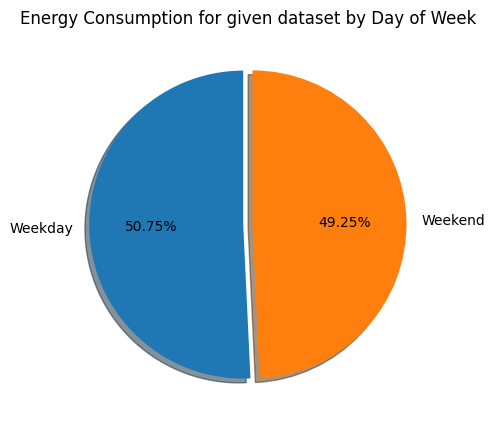

In [14]:
plt.figure(figsize = (10,5))
plt.pie(data_by_day_of_week['Energy Consumption'],
        labels = data_by_day_of_week['Day of Week'],
        autopct = '%1.2f%%',
        startangle = 90,
        shadow = True, 
        explode = [0.03]*len(data_by_day_of_week) )
plt.title('Energy Consumption for given dataset by Day of Week')
plt.show()

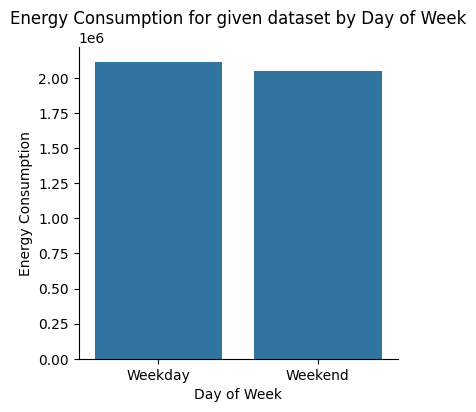

In [15]:
sns.catplot(x = data_by_day_of_week['Day of Week'],
            y = data_by_day_of_week['Energy Consumption'],
            kind = 'bar', height = 4,
            data = data_by_day_of_week )
plt.title('Energy Consumption for given dataset by Day of Week')
plt.show()

In [51]:
train.tail()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
995,Residential,14419,68,44,23.95,Weekend,3661.21
996,Industrial,12194,7,22,14.67,Weekend,3546.34
997,Commercial,39562,88,20,32.18,Weekday,5147.21
998,Residential,8348,67,37,16.48,Weekend,3244.98
999,Commercial,15813,57,11,31.40,Weekend,3423.63


In [52]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   str    
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   str    
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 54.8 KB


#### Step 6: Encoding - train and test data must be encoded

In [67]:
cat_cols=['Building Type','Day of Week']
cat_cols

['Building Type', 'Day of Week']

In [66]:
# from here we have reload our dataset freshly to encode
print(train[cat_cols].head())
print(test_data[cat_cols].head())

  Building Type Day of Week
0   Residential     Weekday
1    Commercial     Weekday
2    Industrial     Weekend
3   Residential     Weekday
4    Commercial     Weekday
  Building Type Day of Week
0   Residential     Weekday
1    Commercial     Weekend
2    Commercial     Weekday
3   Residential     Weekend
4   Residential     Weekday


In [68]:
from sklearn.preprocessing import LabelEncoder

In [69]:
encoders = {}

# Fit encoders on TRAIN and transform TRAIN
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    encoders[col] = le

# Transform TEST with the SAME encoders
for col in cat_cols:
    test_data[col] = encoders[col].transform(test_data[col])

In [72]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        100 non-null    int32  
 1   Square Footage       100 non-null    int64  
 2   Number of Occupants  100 non-null    int64  
 3   Appliances Used      100 non-null    int64  
 4   Average Temperature  100 non-null    float64
 5   Day of Week          100 non-null    int32  
 6   Energy Consumption   100 non-null    float64
dtypes: float64(2), int32(2), int64(3)
memory usage: 4.8 KB


In [73]:
data2 = train.copy()
data2

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,2,7063,76,10,29.84,0,2713.95
1,0,44372,66,45,16.72,0,5744.99
2,1,19255,37,17,14.30,1,4101.24
3,2,13265,14,41,32.82,0,3009.14
4,0,13375,26,18,11.92,0,3279.17
...,...,...,...,...,...,...,...
995,2,14419,68,44,23.95,1,3661.21
996,1,12194,7,22,14.67,1,3546.34
997,0,39562,88,20,32.18,0,5147.21
998,2,8348,67,37,16.48,1,3244.98


#### Step 7: Training and Testing data

In [81]:
from sklearn.model_selection import train_test_split

y = data2['Energy Consumption']
X = data2.drop(columns=['Energy Consumption'])

X_train, X_value, y_train, y_value = train_test_split(
    X,y , test_size = 0.2 , random_state = 42 )

In [79]:
#X_train,y_train        ---- for checking performance

In [78]:
#X_value,y_value

In [82]:
X_train.shape,y_train.shape

((800, 6), (800,))

#### Step 8: Fitting Linear Regression Model

In [83]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [86]:
# Predict on TEST data
X_test = test_data[X_train.columns]
y_test = test_data['Energy Consumption']
test_predictions = model.predict(X_test)

In [87]:
# Save predictions
output = pd.DataFrame({
    'prediction': test_predictions , 
    'actual' : y_test
})
output.to_csv('linear_regression_predictions.csv', index=False)
print(output)
print('Predictions saved to linear_regression_predictions.csv')

     prediction   actual
0   3047.914891  2865.57
1   4533.932593  4283.80
2   5302.485687  5067.83
3   4874.668918  4624.30
4   5075.857853  4820.59
..          ...      ...
95  3259.640333  3010.81
96  4483.684386  4248.49
97  3080.579532  2843.60
98  2826.735286  3348.39
99  4963.209223  4722.59

[100 rows x 2 columns]
Predictions saved to linear_regression_predictions.csv
